**import yfinance dataset**

**Task 2: Predict Future Stock Prices (Short-Term)
Objective:
Use historical stock data to predict the next day's closing price.
Dataset:
Stock market data from Yahoo Finance (retrieved using the yfinance Python library)
Instructions:
● Select a stock (e.g., Apple, Tesla).
● Load historical data using the yfinance library.
● Use features like Open, High, Low, and Volume to predict the next Close price.
● Train a Linear Regression or Random Forest model.
● Plot actual vs predicted closing prices for comparison.
Skills:
● Time series data handling
● Regression modeling
● Data fetching using APIs (yfinance)
● Plotting predictions vs real data**

In [102]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download Apple stock data for the last 2 years
df = yf.download('AAPL', start='2024-01-01', end='2026-03-31')


[*********************100%***********************]  1 of 1 completed


In [103]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.731293,186.502507,181.999286,185.225762,82488700
2024-01-03,182.355591,183.968836,181.544015,182.325900,58414500
2024-01-04,180.039658,181.207518,179.020249,180.277180,71983600
2024-01-05,179.317169,180.880926,178.317559,180.118854,62379700
2024-01-08,183.652130,183.691727,179.633876,180.217806,59144500
...,...,...,...,...,...
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700


In [104]:
print(f"Rows downloaded: {len(df)}")

Rows downloaded: 562


In [105]:


# Download Apple stock data (e.g., last 2 years)


# Create the target: Tomorrow's Close price
df['Next_Close'] = df['Close'].shift(-1)

# Drop the last row because it won't have a 'Next_Close' value
df.dropna(inplace=True)

# Select features and target as per your instructions
x = df[['Open', 'High', 'Low', 'Volume']].values
y = df['Next_Close'].values

In [106]:
x


array([[1.85225762e+02, 1.86502507e+02, 1.81999286e+02, 8.24887000e+07],
       [1.82325900e+02, 1.83968836e+02, 1.81544015e+02, 5.84145000e+07],
       [1.80277180e+02, 1.81207518e+02, 1.79020249e+02, 7.19836000e+07],
       ...,
       [2.54100006e+02, 2.55000000e+02, 2.51600006e+02, 2.84767000e+07],
       [2.52119995e+02, 2.57000000e+02, 2.50770004e+02, 4.17967000e+07],
       [2.53899994e+02, 2.55490005e+02, 2.48070007e+02, 4.79000000e+07]])

In [107]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
y_train

array([269.2567749 , 182.35559082, 189.5904541 , 239.31695557,
       185.75030518, 209.38282776, 171.67179871, 193.42695618,
       237.42745972, 181.64515686, 246.61282349, 219.82598877,
       198.59565735, 186.10664368, 233.78291321, 197.29013062,
       273.50408936, 273.41418457, 219.77215576, 214.90830994,
       194.67758179, 169.82443237, 272.69485474, 171.1920166 ,
       188.38304138, 272.1053772 , 264.57998657, 197.64857483,
       246.63000488, 233.9041748 , 210.5193634 , 226.03520203,
       211.57785034, 225.88616943, 274.23001099, 229.06530762,
       262.51998901, 174.95774841, 241.3316803 , 246.46937561,
       245.9679718 , 229.25404358, 208.20970154, 218.57951355,
       225.58003235, 272.15533447, 219.88165283, 226.0650177 ,
       199.6026001 , 229.21310425, 189.59365845, 247.80812073,
       212.60302734, 215.00714111, 216.28723145, 277.29052734,
       250.82977295, 268.53814697, 182.50405884, 201.76600647,
       169.30914307, 212.56355286, 201.64115906, 206.94

In [108]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [109]:
x_train

array([[ 1.46361995,  1.48229635,  1.4903388 , -0.40483252],
       [-1.2811808 , -1.31371261, -1.33036152,  1.08584842],
       [-1.31592708, -1.29083718, -1.2662091 ,  0.913642  ],
       ...,
       [ 0.44597062,  0.435572  ,  0.47125479,  0.05518363],
       [ 0.9839566 ,  1.01762387,  1.05181277, -0.31289997],
       [-1.18416912, -1.17265693, -1.12801141, -0.04432033]])

**Using RandomForest Regressor**

In [110]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train
model = RandomForestRegressor(n_estimators=100, random_state=42)
from sklearn.metrics import mean_absolute_error,r2_score
model.fit(x_train, y_train)

# Make predictions
y_predict = model.predict(x_test)

In [111]:
model.score(x_test,y_test)

0.9830225598321138

In [112]:
mae=mean_absolute_error(y_test,y_predict)
r2=r2_score(y_test,y_predict)

In [113]:
mae

3.083501060283289

In [114]:
r2

0.9830225598321138

**Using Linear Regression**

In [115]:

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train),
model.score(x_train,y_train)

0.9820964047374376

In [116]:
mae=mean_absolute_error(y_test,y_predict)
r2=r2_score(y_test,y_predict)

In [117]:
mae

3.083501060283289

In [118]:
r2

0.9830225598321138

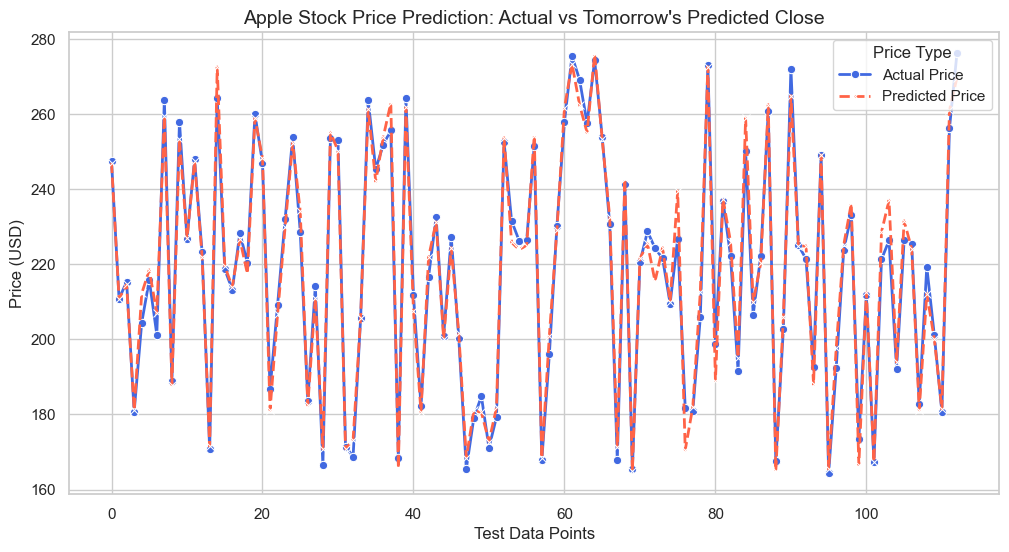

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the visual style (Standard for clean, professional plots)
sns.set_theme(style="whitegrid")

# 2. Prepare the figure
plt.figure(figsize=(12, 6))

# 3. Plot Actual vs Predicted using Seaborn lineplot
# We use 'label' to ensure they show up in the legend automatically
sns.lineplot(data=results['Actual'].values, color="royalblue", label="Actual Price", marker="o", linewidth=2)
sns.lineplot(data=results['Predicted'].values, color="tomato", label="Predicted Price", marker="x", linestyle="--", linewidth=2)

# 4. Final touches
plt.title('Apple Stock Price Prediction: Actual vs Tomorrow\'s Predicted Close', fontsize=14)
plt.xlabel('Test Data Points', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(title="Price Type") # Adds a nice title to the legend

plt.show()